## LASACO STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

lasaco=pd.read_csv('../stock_data/lasaco.csv') ## so it can be small letter. This is cool.
lasaco=lasaco.drop(columns=['high_price','low_price'])
lasaco.rename(columns={'trade_date':'date'},inplace=True)
lasaco['date']=pd.to_datetime(lasaco['date'])
lasaco['month']=lasaco['date'].dt.month
lasaco['quarter']=lasaco['date'].dt.quarter
lasaco['year']=lasaco['date'].dt.year

lasaco

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42815,LASACO,2017-01-03,0.50,0.50,0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43375,LASACO,2017-01-04,0.50,0.50,323858,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43485,LASACO,2017-01-05,0.50,0.50,2075000,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43595,LASACO,2017-01-06,0.50,0.50,95000,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43685,LASACO,2017-01-09,0.50,0.50,113087,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298083,LASACO,2026-07-13,1.93,1.93,893807,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298521,LASACO,2026-07-14,1.94,1.94,513064,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298959,LASACO,2026-07-15,1.97,1.97,921983,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299397,LASACO,2026-07-16,1.90,1.90,1227663,2026-07-16T15:10:03.113936+00:00,7,3,2026


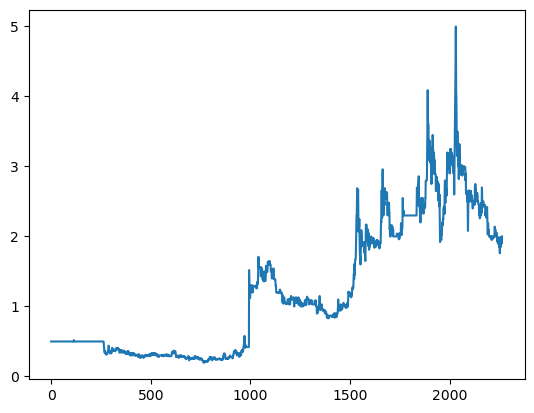

In [2]:
import matplotlib.pyplot as plt

plt.plot(lasaco['close_price'])
plt.show()

In [3]:
lasaco_end_month_df = (
    lasaco
    .sort_values("date")
    .groupby(lasaco["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

lasaco_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45385,LASACO,2017-01-31,0.50,0.50,0,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47207,LASACO,2017-02-28,0.50,0.50,15000,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49323,LASACO,2017-03-31,0.50,0.50,0,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51151,LASACO,2017-04-28,0.50,0.50,0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53073,LASACO,2017-05-31,0.50,0.50,2400,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35320,LASACO,2026-03-31,2.03,2.03,26435775,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281146,LASACO,2026-04-30,1.95,1.95,90199834,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284212,LASACO,2026-05-29,2.10,2.10,2349764,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294140,LASACO,2026-06-30,1.94,1.94,3333549,2026-06-30T15:10:03.08168+00:00,6,2,2026


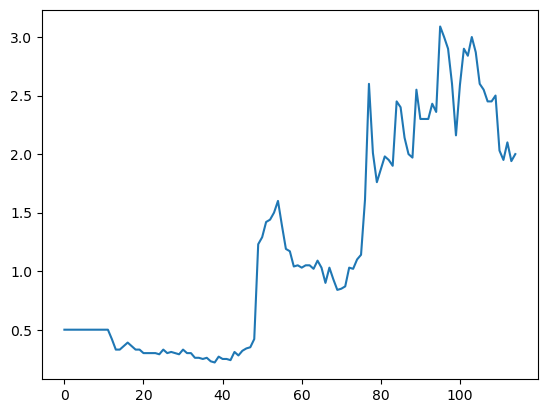

In [4]:
plt.plot(lasaco_end_month_df['close_price'])
plt.show()

In [5]:
lasaco_end_month_df['returns']=lasaco_end_month_df['close_price'].pct_change()*100
lasaco_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45385,LASACO,2017-01-31,0.50,0.50,0,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47207,LASACO,2017-02-28,0.50,0.50,15000,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49323,LASACO,2017-03-31,0.50,0.50,0,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51151,LASACO,2017-04-28,0.50,0.50,0,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53073,LASACO,2017-05-31,0.50,0.50,2400,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35320,LASACO,2026-03-31,2.03,2.03,26435775,2026-03-31T15:00:02.085058+00:00,3,1,2026,-18.800000
111,281146,LASACO,2026-04-30,1.95,1.95,90199834,2026-04-30T15:00:02.170664+00:00,4,2,2026,-3.940887
112,284212,LASACO,2026-05-29,2.10,2.10,2349764,2026-05-29T15:00:02.455558+00:00,5,2,2026,7.692308
113,294140,LASACO,2026-06-30,1.94,1.94,3333549,2026-06-30T15:10:03.08168+00:00,6,2,2026,-7.619048


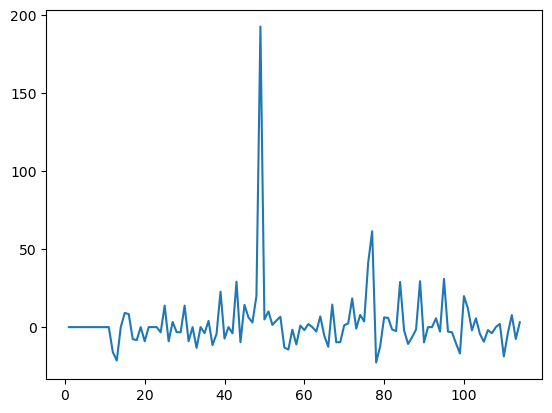

In [6]:
plt.plot(lasaco_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(lasaco_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-9.684452349055352, 1.1807633012572462e-16, 0, 113, {'1%': -3.489589552580676, '5%': -2.887477210140433, '10%': -2.580604145195395}, 912.903965415129)
stationary


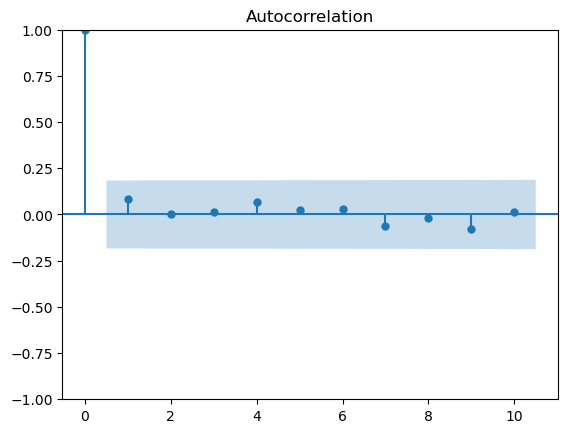

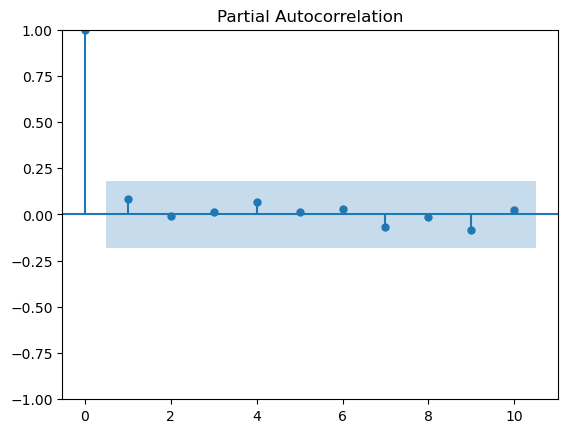

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(lasaco_end_month_df['returns'].dropna(), lags=10)
plot_pacf(lasaco_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=lasaco_end_month_df['close_price'][:-10]
test=lasaco_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -75.57824067892165]
[0, 0, 0, 0, 0, 1, -20.1796120373141]
[0, 0, 0, 0, 0, 2, -3.9119692091602056]
[0, 0, 0, 0, 1, 0, -3.7082387501669087]
[0, 0, 0, 0, 1, 1, -3.628435166374323]
[0, 0, 0, 0, 1, 2, -6.784252509249792]
[0, 0, 0, 0, 2, 0, -16.130458004620163]
[0, 0, 0, 0, 2, 1, -10.775112304774588]
[0, 0, 0, 0, 2, 2, -17.409187526149196]
[0, 0, 0, 1, 0, 0, -1.9703864785063274]
[0, 0, 0, 1, 0, 1, -1.9629358940500579]
[0, 0, 0, 1, 0, 2, -3.81024321640371]
[0, 0, 0, 1, 1, 0, -3.5853966815662]
[0, 0, 0, 1, 1, 1, -2.4868769387215353]
[0, 0, 0, 1, 1, 2, -9.99243861816662]
[0, 0, 0, 1, 2, 0, -21.428634349146634]
[0, 0, 0, 1, 2, 1, -16.052155334772184]
[0, 0, 0, 1, 2, 2, -17.557691403580293]
[0, 0, 0, 2, 0, 0, -1.9587734326284605]
[0, 0, 0, 2, 0, 1, -1.0396810081229608]
[0, 0, 0, 2, 0, 2, -5.761217808444621]
[0, 0, 0, 2, 1, 0, -8.738866726040042]
[0, 0, 0, 2, 1, 1, -9.57826513874142]
[0, 0, 0, 2, 1, 2, -9.464027423783316]
[0, 0, 0, 2, 2, 0, -17.59425194363619]
[0, 0, 0, 2, 2, 1,

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
466,1,2,2,0,2,1,-791029.349550
0,0,0,0,0,0,0,-75.578241
27,0,0,1,0,0,0,-69.135060
54,0,0,2,0,0,0,-65.328982
656,2,2,0,0,2,2,-42.385426
...,...,...,...,...,...,...,...
172,0,2,0,1,0,1,0.600697
171,0,2,0,1,0,0,0.606190
173,0,2,0,1,0,2,0.607865
182,0,2,0,2,0,2,0.614940


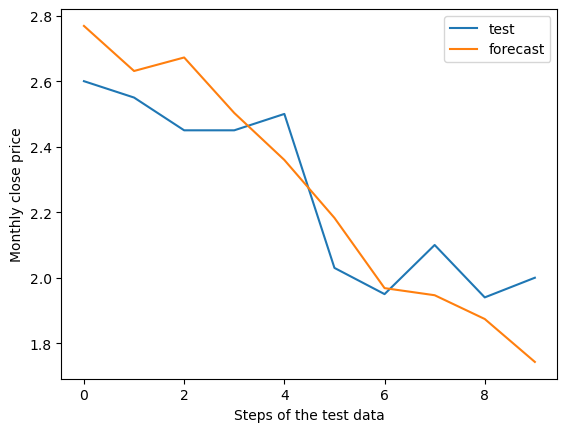

r2_score:  0.6668905218705472
rmse:  0.14983962071295848
description:  count    115.000000
mean       1.208783
std        0.905052
min        0.220000
25%        0.330000
50%        1.030000
75%        2.000000
max        3.090000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=lasaco_end_month_df['close_price'][:-10]
y_test=lasaco_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,0), 
seasonal_order=(0,0,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', lasaco_end_month_df.close_price.describe())

This is good.